Probleam statement interpretation:
An airline company wants to predict whether a flight will be delayed so that the Passengers would be better informed if it my delay.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


In [3]:
import os

for file in os.listdir(path):
    print(file)

airports.csv
airlines.csv
flights.csv


In [20]:
import pandas as pd

df = pd.read_csv(f"{path}/flights.csv")

print(df.shape)

/tmp/ipykernel_1350/2931041952.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/flights.csv")


(5819079, 31)


In [21]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

Dataset contains 5819079 rows flight records and 31 columns.

Numerical features are represented using int64 and float64 datatypes. Categorical variables such as AIRLINE and AIRPORT codes are stored as object datatype.Dataset size is approximately 1.3 GB. Data includes scheduling information, airport details, delay information, and cancellation records.

In [6]:
# Checked the number of missing values in each row.
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
dtype: int64


In [7]:
df["Flight_Delayed"] = (df["ARRIVAL_DELAY"] > 15).astype(int)

print(df["Flight_Delayed"].value_counts(dropna=False))
print(df["Flight_Delayed"].value_counts(normalize=True) * 100)


Flight_Delayed
0    4795581
1    1023498
Name: count, dtype: int64
Flight_Delayed
0    82.41134
1    17.58866
Name: proportion, dtype: float64


Here we see is 82% flights are not delayed and 17.5 are delayed. And below is the visual representation of it.

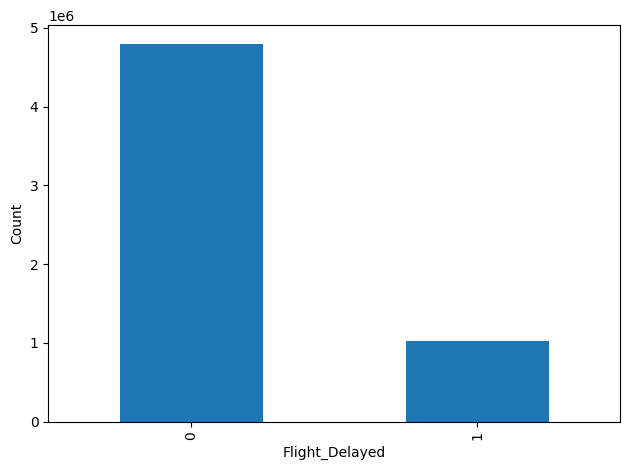

In [8]:
import matplotlib.pyplot as plt

df["Flight_Delayed"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

corr = df[num_cols].corr()

print(corr["ARRIVAL_DELAY"].sort_values(ascending=False).head(10))

ARRIVAL_DELAY          1.000000
DEPARTURE_DELAY        0.944672
Flight_Delayed         0.668740
AIRLINE_DELAY          0.609351
LATE_AIRCRAFT_DELAY    0.522013
WEATHER_DELAY          0.264799
AIR_SYSTEM_DELAY       0.247187
TAXI_OUT               0.227319
DEPARTURE_TIME         0.159787
WHEELS_OFF             0.155773
Name: ARRIVAL_DELAY, dtype: float64


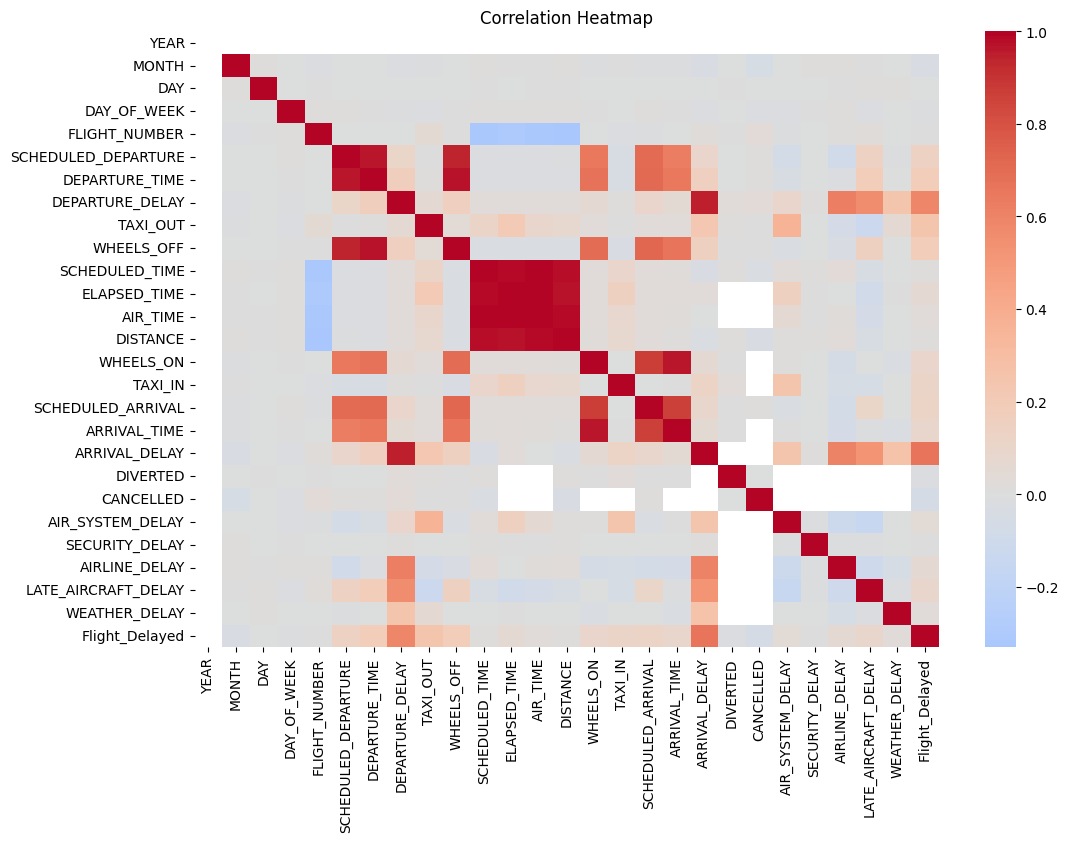

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(
    df[num_cols].corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
print(df.columns.tolist())

['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'Flight_Delayed']


In [10]:
print(df["CANCELLED"].value_counts())
print(df["DIVERTED"].value_counts())

CANCELLED
0    5729195
1      89884
Name: count, dtype: int64
DIVERTED
0    5803892
1      15187
Name: count, dtype: int64


In [12]:
df_model = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)]

print(df_model.shape)

(5714008, 32)


In [13]:
print(df_model["Flight_Delayed"].isnull().sum())
print(df_model["Flight_Delayed"].value_counts())

0
Flight_Delayed
0    4690510
1    1023498
Name: count, dtype: int64


In [14]:
features = [
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE',
    'FLIGHT_NUMBER',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

X = df_model[features]
y = df_model['Flight_Delayed']

print(X.shape)
print(y.shape)

(5714008, 11)
(5714008,)


So this features were selected because features which are available before flighting taking off are to be more rational to work with because it is prediction afterall.

In [15]:
print(X.dtypes)

MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
SCHEDULED_TIME         float64
DISTANCE                 int64
SCHEDULED_ARRIVAL        int64
dtype: object


In [16]:
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    print(col, X[col].nunique())


AIRLINE 14
ORIGIN_AIRPORT 929
DESTINATION_AIRPORT 929


Here We checked for cardinality as it is categorical data we need to do Encoding accordingly.

In [17]:
from sklearn.preprocessing import LabelEncoder

X_enc = X.copy()

for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))

print(X_enc.head())

   MONTH  DAY  DAY_OF_WEEK  AIRLINE  FLIGHT_NUMBER  ORIGIN_AIRPORT  \
0      1    1            4        1             98             323   
1      1    1            4        0           2336             482   
2      1    1            4       11            840             584   
3      1    1            4        0            258             482   
4      1    1            4        1            135             583   

   DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  SCHEDULED_TIME  DISTANCE  \
0                  584                    5           205.0      1448   
1                  542                   10           280.0      2330   
2                  373                   20           286.0      2296   
3                  510                   20           285.0      2342   
4                  324                   25           235.0      1448   

   SCHEDULED_ARRIVAL  
0                430  
1                750  
2                806  
3                805  
4                320  


In [17]:
from sklearn.model_selection import train_test_split

X_sample = X_enc.sample(n=200000, random_state=42)
y_sample = y.loc[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print(X_train.shape)
print(X_test.shape)

(160000, 11)
(40000, 11)


Made Training testing split.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Model Trained")

Model Trained


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.816475

Confusion Matrix:
[[32242   629]
 [ 6712   417]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     32871
           1       0.40      0.06      0.10      7129

    accuracy                           0.82     40000
   macro avg       0.61      0.52      0.50     40000
weighted avg       0.75      0.82      0.76     40000



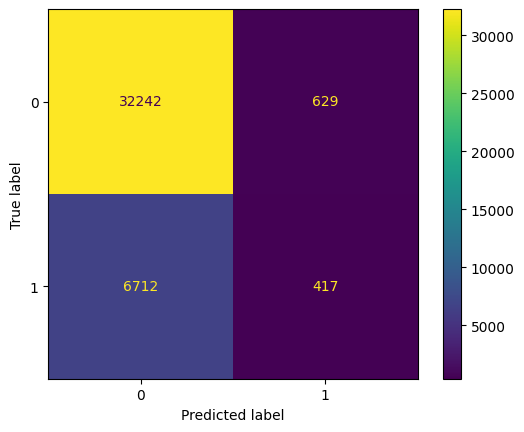

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90     32871
           1       0.42      0.05      0.09      7129

    accuracy                           0.82     40000
   macro avg       0.62      0.52      0.49     40000
weighted avg       0.75      0.82      0.75     40000



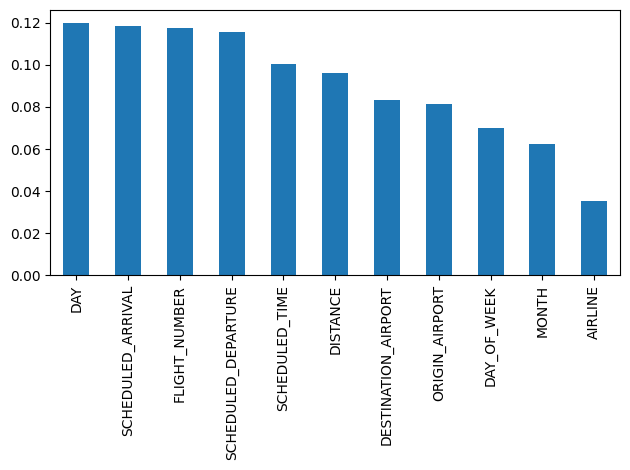

DAY                    0.120035
SCHEDULED_ARRIVAL      0.118564
FLIGHT_NUMBER          0.117270
SCHEDULED_DEPARTURE    0.115484
SCHEDULED_TIME         0.100320
DISTANCE               0.095885
DESTINATION_AIRPORT    0.083361
ORIGIN_AIRPORT         0.081509
DAY_OF_WEEK            0.069887
MONTH                  0.062367
AIRLINE                0.035318
dtype: float64


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.plot(kind='bar')
plt.tight_layout()
plt.show()

print(importance)

In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

DAY                    0.120035
SCHEDULED_ARRIVAL      0.118564
FLIGHT_NUMBER          0.117270
SCHEDULED_DEPARTURE    0.115484
SCHEDULED_TIME         0.100320
DISTANCE               0.095885
DESTINATION_AIRPORT    0.083361
ORIGIN_AIRPORT         0.081509
DAY_OF_WEEK            0.069887
MONTH                  0.062367
AIRLINE                0.035318
dtype: float64


#**Final Recommendation and Decision-Making Summary**

The flight delay prediction model achieved an accuracy of 81.65% and demonstrated the potential of machine learning to support airline operations. The analysis showed that scheduling-related factors such as departure time, arrival time, flight duration, and travel distance significantly influence flight delays.

It is recommended that the airline use the model as an early-warning system to identify flights that are likely to be delayed. This can help improve passenger communication, optimize crew and gate allocation, and support operational planning.

To improve prediction performance, additional features such as weather conditions, airport congestion, and air traffic information should be incorporated in future versions of the model.

Overall, the solution can help the airline make proactive decisions, improve operational efficiency, and enhance passenger satisfaction.

#Q2

In [18]:
import pandas as pd

df = pd.read_excel('/content/Resume.xlsx')

print(df.shape)
print(df.columns.tolist())

(2484, 4)
['ID', 'Resume_str', 'Resume_html', 'Category']


In [19]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [25]:
print(df['Category'].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


Checked for null values in columns

In [26]:
print(df.isnull().sum())

ID             0
Resume_str     1
Resume_html    3
Category       0
dtype: int64


As nulls are negligible we dropped them.

In [27]:
df = df.dropna(subset=['Resume_str'])

print(df.shape)

(2483, 4)


In [28]:
print("Duplicate Resumes:", df['Resume_str'].duplicated().sum())

Duplicate Resumes: 2


In [29]:
df = df.drop_duplicates(subset=['Resume_str'])

print(df.shape)


(2481, 4)


Heere we checked length of the resume.

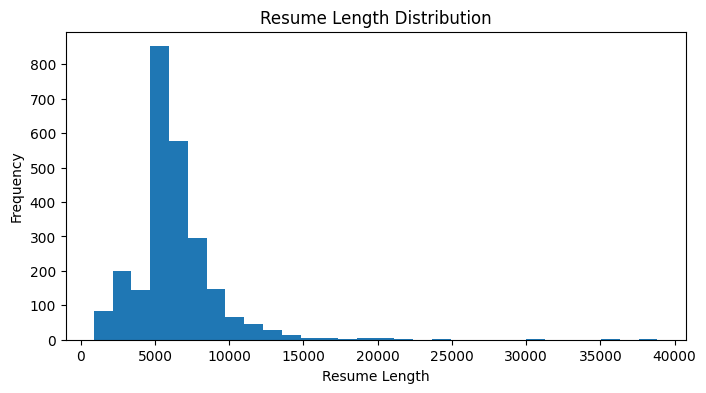

In [30]:
import matplotlib.pyplot as plt

df['resume_length'] = df['Resume_str'].astype(str).apply(len)

plt.figure(figsize=(8,4))
plt.hist(df['resume_length'], bins=30)
plt.xlabel('Resume Length')
plt.ylabel('Frequency')
plt.title('Resume Length Distribution')
plt.show()

In [31]:
df['resume_length'] = df['Resume_str'].astype(str).apply(len)

print(df['resume_length'].describe())

count     2481.000000
mean      6298.713422
std       2767.887213
min        881.000000
25%       5160.000000
50%       5889.000000
75%       7228.000000
max      38842.000000
Name: resume_length, dtype: float64


Splitted the Data into training and testing data.

In [32]:
from sklearn.model_selection import train_test_split

X = df['Resume_str']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1984,)
(497,)


TF-IDF is used to convert resume text into numerical features.
It highlights important keywords and removes common words.
These numerical features are then used by the machine learning model for resume classification.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(1984, 5000)
(497, 5000)


Multinomial Naive Bayes is used as a baseline classification model for text data.
It works well with TF-IDF features because it predicts categories based on the probability of words appearing in each class.
The model is trained using the TF-IDF transformed training data and learns the relationship between resume keywords and job categories.
After training, predictions are made on unseen test resumes.
Accuracy is then calculated to measure how correctly the model classifies resumes into their respective categories.

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5492957746478874


Naive Bayes provided baseline performance but achieved only 54.93% accuracy.
To improve classification performance, Linear SVM was used because it performs well on high-dimensional text data.
TF-IDF was enhanced with unigram and bigram features to capture both individual keywords and meaningful phrases.
The model was trained on the transformed resume data and evaluated on unseen test resumes.
The improved approach achieved higher accuracy and was selected as the final model.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

pred = svm.predict(X_test_tfidf)

print("Improved SVM Accuracy:", accuracy_score(y_test, pred))

Improved SVM Accuracy: 0.7223340040241448


In [22]:
# BUSINESS INTERPRETATION
# The objective of this project was to automate resume screening and candidate categorization for a recruitment company.
# Resume text was analyzed using NLP techniques and transformed into numerical features using TF-IDF vectorization.
# Multiple machine learning models were evaluated to identify the most effective approach for resume classification.
#
# RESULTS
# Naive Bayes achieved an accuracy of 54.93% and served as the baseline model.
# Linear SVM with TF-IDF unigram and bigram features achieved the highest accuracy of 72.23%.
# The higher accuracy indicates that the model can effectively identify job categories based on resume content and skills.
#
# BUSINESS RECOMMENDATIONS
# 1. Deploy the Linear SVM model as the primary resume screening system.
# 2. Automatically categorize incoming resumes into relevant job domains.
# 3. Reduce recruiter workload by eliminating manual initial screening.
# 4. Prioritize candidates based on category matching and skill relevance.
# 5. Continuously retrain the model using newly received resumes to improve performance.
#
# DECISION-MAKING SUMMARY
# Based on model comparison, Linear SVM with TF-IDF unigram and bigram features was selected as the final model because it achieved the highest accuracy of 72.23%.
# The solution can improve candidate screening efficiency, reduce hiring time, support better recruitment decisions, and provide a scalable approach for handling large volumes of resumes.